# PVGIS-only ST-GNN + SDE-Net — no-PV-lag ablation

Reproducible orchestrator for the final run on server **newzealand**.

Does **not** duplicate runner/analysis logic — it builds commands and reads the
CSVs they write, via `physiq_pv.experiments.sde_pipeline`.

Safety switches: `RUN_TRAINING`, `RUN_ANALYSIS`, `LOG_TO_WANDB`.

The selected experiment uses the paper regression likelihood: Gaussian NLL with beta=0. This ablation removes only `pv_lag_pvgis`; detector, split, seed, architecture and all other hyperparameters remain unchanged. Run the notebook from the config cell onward; the results section reads only that run's output directory.

## 1. Setup

In [1]:
import os, sys, subprocess
from pathlib import Path
import pandas as pd

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))
os.environ['PYTHONPATH'] = str(REPO_ROOT) + os.pathsep + os.environ.get('PYTHONPATH', '')
os.chdir(REPO_ROOT)

from physiq_pv.experiments import sde_pipeline as pipe
print('repo root:', REPO_ROOT)

repo root: /home/apedalino/physiq_pv


In [2]:
PVGIS_DIR = pipe.PVGIS_DIR
EXPERIMENT = 'paper_faithful_gaussian_no_pv_lag'
TRAIN_NORMAL_ONLY = False  # True rimuove gli eventi rari da train/validation
ANOMALY_SOURCE = 'detector'  # 'climatology' | 'detector'
DETECTOR = 'mtgflow'  # 'mtgflow' | 'catch' | 'm2ad'
DETECTOR_SEED = 15
DETECTOR_ROOTS = {
    'mtgflow': Path('outputs/pvgis_mtgflow/downstream_dense') / f'seed_{DETECTOR_SEED}',
    'catch': Path('outputs/pvgis_catch_2005_2019'),
    'm2ad': Path('outputs/pvgis_m2ad_2005_2019'),
}
DETECTOR_ROOT = DETECTOR_ROOTS[DETECTOR]
if ANOMALY_SOURCE == 'detector':
    TEST_ANOMALY_SCORES = str(DETECTOR_ROOT / 'anomaly_scores.csv')
    TRAIN_ANOMALY_SCORES = str(DETECTOR_ROOT / 'train_anomaly_scores.csv')
else:
    TEST_ANOMALY_SCORES = pipe.TEST_ANOMALY_SCORES
    TRAIN_ANOMALY_SCORES = pipe.TRAIN_ANOMALY_SCORES
ANALYSIS_SCRIPT = pipe.ANALYSIS_SCRIPT

NEEDS_TRAIN_ANOMALIES = bool(TRAIN_NORMAL_ONLY) or ANOMALY_SOURCE == 'detector'
checks = {
    'PVGIS dir': Path(PVGIS_DIR).is_dir(),
    'test anomaly scores': Path(TEST_ANOMALY_SCORES).exists(),
    'train anomaly scores': (not NEEDS_TRAIN_ANOMALIES) or Path(TRAIN_ANOMALY_SCORES).exists(),
    'analysis script': Path(ANALYSIS_SCRIPT).exists(),
}
try:
    import physiq_pv.experiments.pvgis_stgnn_runner  # noqa: F401
    checks['runner importable'] = True
except Exception as e:
    checks['runner importable'] = False
    print('runner import error:', e)
for k, v in checks.items():
    print(('OK     ' if v else 'MISSING') + '  ' + k)

OK       PVGIS dir
OK       test anomaly scores
OK       train anomaly scores
OK       analysis script
OK       runner importable


If the anomaly scores are **missing**, regenerate them (run in a terminal — not launched automatically):

In [3]:
if not Path(TEST_ANOMALY_SCORES).exists() or (NEEDS_TRAIN_ANOMALIES and not Path(TRAIN_ANOMALY_SCORES).exists()):
    if ANOMALY_SOURCE == 'detector':
        detector_notebook = {'mtgflow': 'mtgflow_pvgis_workflow.ipynb', 'catch': 'pvgis_catch_pipeline.ipynb', 'm2ad': 'pvgis_m2ad_pipeline.ipynb'}[DETECTOR]
        print(f'Mancano i CSV {DETECTOR}: eseguire prima notebooks/{detector_notebook}')
    else:
        base = ('PYTHONPATH=$PWD python scripts/run_pvgis_climatology_anomaly_years.py'
            ' --pvgis-dir ' + PVGIS_DIR +
            ' --climatology-start-year 2005 --climatology-end-year 2018'
            ' --rolling-past-climatology'
            ' --quantile 0.975 --climatology-window-days 15 --min-climatology-years 3'
            ' --variables solar_irradiance_poa pv_power_output temperature_2m wind_speed_10m'
            ' --out-root outputs')
        print('# Test year 2019:')
        print(base + ' --years 2019')
        print()
        print('# Train years 2016-2018 (aggregated):')
        print(base + ' --years 2016,2017,2018 --aggregate-out-dir ' + str(Path(TRAIN_ANOMALY_SCORES).parent))
else:
    print('anomaly scores present.')

anomaly scores present.


## 2. Single-run config

In [4]:
# === EXPERIMENT SELECTOR ===
# Paper-faithful SDE-Net regression ablation: remove only pv_lag_pvgis.
# Everything else matches the full-feature detector run.
BASE_CONFIG = {**pipe.DEFAULT_CONFIG,
    'name': f'paper_faithful_gaussian_no_pv_lag_{ANOMALY_SOURCE}_{DETECTOR}_ep60',
    'feature_set': 'no_pv_lag',
    'epochs': 60, 'batch_size': 16, 'lr': 1e-4, 'lr_g': 1e-2,
    'dropout': 0.0, 'train_normal_only': TRAIN_NORMAL_ONLY,
    'n_sde_steps': 4, 'sigma_max': 0.5,
    'sde_sigma_initial': 0.01, 'sde_sigma_warmup_epochs': 30,
    'ood_noise_std': 2.0, 'mc_samples': 10, 'seed': 1,
    'ood_smoke_test': True, 'ood_smoke_max_samples': 2048,
               'anomaly_source': ANOMALY_SOURCE,
               'detector_regional_quantile': 0.975,
}

out_dir = pipe.make_out_dir(BASE_CONFIG)
run_name = pipe.make_run_name(BASE_CONFIG)
print('experiment:', EXPERIMENT)
print('config    :', BASE_CONFIG)
print('out_dir   :', out_dir)
print('run_name  :', run_name)
if Path(out_dir).exists():
    print('NOTICE: out_dir already exists; the execution guard below will block reuse.')

experiment: paper_faithful_gaussian_no_pv_lag
config    : {'train_years': '2016,2017,2018', 'test_year': 2019, 'seq_len': 24, 'horizon': 1, 'target_variable': 'pv_power_output', 'model_type': 'stgnn', 'feature_set': 'no_pv_lag', 'epochs': 60, 'batch_size': 16, 'lr': 0.0001, 'lr_g': 0.01, 'dropout': 0.0, 'mc_samples': 10, 'seed': 1, 'n_sde_steps': 4, 'sigma_max': 0.5, 'sde_sigma_initial': 0.01, 'sde_sigma_warmup_epochs': 30, 'ood_noise_std': 2.0, 'ood_smoke_test': True, 'ood_smoke_max_samples': 2048, 'gradient_clip_norm': 100.0, 'lr_decay_epoch': 20, 'lr_decay_factor': 0.1, 'irradiance_loss_weight': 0.1, 'pv_target_clip_max': 'none', 'kt_poa_max': 1.6, 'distance_scale_km': 10.0, 'edge_prior_strength': 1.0, 'validation_metric': 'rmse_daytime', 'early_stopping_patience': 10, 'early_stopping_min_delta': 0.0, 'anomaly_source': 'detector', 'event_spatial_quantile': 0.99, 'event_tail_quantile': 0.975, 'detector_regional_quantile': 0.975, 'detector_min_temporal_coverage': 0.95, 'name': 'paper_

## 3. Training command

In [5]:
train_cmd = pipe.build_train_command(
    BASE_CONFIG, out_dir=out_dir, run_name=run_name,
    pvgis_dir=PVGIS_DIR, test_anomaly_scores=TEST_ANOMALY_SCORES,
    train_anomaly_scores=TRAIN_ANOMALY_SCORES, device='cuda', use_wandb=True)
# Keep W&B run logging enabled, but do not upload runner artifacts.
assert '--wandb' in train_cmd
assert '--no-wandb-upload-artifacts' in train_cmd
print(' \\\n  '.join(train_cmd))

/home/apedalino/physiq_pv/.venv/bin/python \
  -m \
  physiq_pv.experiments.pvgis_stgnn_runner \
  --pvgis-dir \
  /data/SentinelPV/pvgis_data/data/pvgis_summed_irradiance \
  --anomaly-scores \
  outputs/pvgis_mtgflow/downstream_dense/seed_15/anomaly_scores.csv \
  --train-years \
  2016,2017,2018 \
  --test-year \
  2019 \
  --seq-len \
  24 \
  --horizon \
  1 \
  --target-variable \
  pv_power_output \
  --model-type \
  stgnn \
  --feature-set \
  no_pv_lag \
  --irradiance-loss-weight \
  0.1 \
  --epochs \
  60 \
  --batch-size \
  16 \
  --lr \
  0.0001 \
  --lr-g \
  0.01 \
  --dropout \
  0.0 \
  --mc-samples \
  10 \
  --pv-target-clip-max \
  none \
  --seed \
  1 \
  --n-sde-steps \
  4 \
  --sigma-max \
  0.5 \
  --sde-sigma-initial \
  0.01 \
  --sde-sigma-warmup-epochs \
  30 \
  --ood-noise-std \
  2.0 \
  --ood-smoke-max-samples \
  2048 \
  --gradient-clip-norm \
  100.0 \
  --lr-decay-epoch \
  20 \
  --lr-decay-factor \
  0.1 \
  --kt-poa-max \
  1.6 \
  --distance

## 4. Run training

Set `RUN_TRAINING = True` to actually launch.

In [ ]:
RUN_TRAINING = True
EVAL_ONLY_PREDICTIONS = None  # path a predictions.csv esistente; richiede RUN_TRAINING=False
ALLOW_OVERWRITE = False

if RUN_TRAINING and EVAL_ONLY_PREDICTIONS:
    raise ValueError('Scegliere training oppure evaluation-only, non entrambi.')
if RUN_TRAINING:
    pipe.ensure_output_dir_available(out_dir, allow_overwrite=ALLOW_OVERWRITE)
    subprocess.run(train_cmd, check=True)
elif EVAL_ONLY_PREDICTIONS:
    eval_paths = pipe.relabel_detector_predictions_file(
        EVAL_ONLY_PREDICTIONS,
        TEST_ANOMALY_SCORES,
        TRAIN_ANOMALY_SCORES,
        out_dir,
        regional_quantile=BASE_CONFIG['detector_regional_quantile'],
        min_temporal_coverage=BASE_CONFIG['detector_min_temporal_coverage'],
        allow_overwrite=ALLOW_OVERWRITE,
    )
    print('Evaluation-only outputs:', eval_paths)
else:
    print('Training ed evaluation-only disattivati.')

## 5. Post-hoc analysis

In [6]:
RUN_ANALYSIS = True

analysis_cmd = pipe.build_analysis_command(out_dir, BASE_CONFIG)
print(' \\\n  '.join(analysis_cmd))
if RUN_ANALYSIS:
    subprocess.run(analysis_cmd, check=True)
else:
    print('RUN_ANALYSIS is False — not launching.')

/home/apedalino/physiq_pv/.venv/bin/python \
  scripts/analyze_pvgis_daytime_report.py \
  --predictions \
  outputs/pvgis_stgnn_paper_faithful_gaussian_no_pv_lag_detector_mtgflow_ep60_seed1/predictions.csv \
  --out-dir \
  outputs/pvgis_stgnn_paper_faithful_gaussian_no_pv_lag_detector_mtgflow_ep60_seed1 \
  --epochs \
  60 \
  --dropout \
  0.0 \
  --mc-samples \
  10
[load] scanned 10,037,664 rows; 4,747,545 daytime candidates (solar > 10.0 W/m^2); kept 4,747,545 valid, skipped 0 invalid; 5,290,119 nighttime
[sharpness] target_range = 891.8600 (y_true_min 1.4100, y_true_max 893.2700)
[done] wrote:
  outputs/pvgis_stgnn_paper_faithful_gaussian_no_pv_lag_detector_mtgflow_ep60_seed1/daytime_bin_anomaly_report.md
  outputs/pvgis_stgnn_paper_faithful_gaussian_no_pv_lag_detector_mtgflow_ep60_seed1/daytime_anomaly_overview.csv
  outputs/pvgis_stgnn_paper_faithful_gaussian_no_pv_lag_detector_mtgflow_ep60_seed1/daytime_bin_summary.csv
  outputs/pvgis_stgnn_paper_faithful_gaussian_no_pv_lag_d

## 6. Results & figures

Reads the CSVs the runner/analysis wrote, then shows: summary tables, the
SDE band (predictive std) by anomaly group, and the post-hoc figures
(per-sample MAE/NMPIL boxplots + pooled PICP/CLC bar charts, one figure per
production-percentage bin, split by anomaly category). The ST-GNN SDE head
reports epistemic and aleatoric components separately.

In [7]:
def _read(name):
    p = Path(out_dir) / name
    return pd.read_csv(p) if p.exists() else None

RESULT_FILES = ['metrics_global.csv','metrics_daytime.csv','metrics_by_anomaly_label.csv',
                'residual_bias_and_bin_metrics.csv','daytime_bin_summary.csv',
                'daytime_bin_anomaly_metrics.csv','frequency_weighted_bin_summary.csv',
                'uncertainty_response.csv','sharpness_overview.csv']
results = {n: _read(n) for n in RESULT_FILES}
for n, df in results.items():
    print((('OK  ' if df is not None else '--  ') + n) + (('  ' + str(df.shape)) if df is not None else ''))

OK  metrics_global.csv  (1, 9)
OK  metrics_daytime.csv  (12, 26)
OK  metrics_by_anomaly_label.csv  (4, 9)
OK  residual_bias_and_bin_metrics.csv  (19, 24)
OK  daytime_bin_summary.csv  (5, 9)
OK  daytime_bin_anomaly_metrics.csv  (30, 25)
OK  frequency_weighted_bin_summary.csv  (6, 14)
OK  uncertainty_response.csv  (5, 10)
OK  sharpness_overview.csv  (7, 11)


In [8]:
sharp = results['sharpness_overview.csv']
if sharp is not None:
    cols = [c for c in ['scope','count','picp','mae','rmse','mean_std','mpiw','nmpil'] if c in sharp.columns]
    display(sharp[cols])
bins = results['daytime_bin_summary.csv']
if bins is not None:
    display(bins)
freq = results['frequency_weighted_bin_summary.csv']
if freq is not None:
    display(freq)
unc = results['uncertainty_response.csv']
if unc is not None:
    display(unc)

,scope,count,picp,mae,rmse,mean_std,mpiw,nmpil
0,overall_daytime,4747545,0.959341,42.682265,69.312738,58.484264,229.254235,0.257052
1,normal,4547069,0.959507,42.465630,68.941816,58.235131,228.277636,0.255957
2,rare_extreme,200476,0.955576,47.595843,77.248913,64.134935,251.404830,0.281888
3,unusually_low_solar_potential,0,NaN,NaN,NaN,NaN,NaN,NaN
4,unusually_high_solar_potential,0,NaN,NaN,NaN,NaN,NaN,NaN
5,extreme_temperature_condition,0,NaN,NaN,NaN,NaN,NaN,NaN
6,extreme_wind_condition,0,NaN,NaN,NaN,NaN,NaN,NaN


,bin,count,mae,rmse,picp,mean_std,mpiw,nmpil,production_peak_nmpil
0,daytime_0_20_pct,1934608,38.193049,65.345623,0.953830,45.119334,176.864643,0.198310,0.248076
1,daytime_20_40_pct,856630,47.114760,69.145539,0.947798,68.180093,267.261161,0.299667,0.374869
2,daytime_40_60_pct,736468,47.044367,70.827548,0.961481,72.059417,282.467845,0.316718,0.396198
3,daytime_60_80_pct,669745,46.241942,77.122811,0.968751,69.458078,272.270877,0.305284,0.381896
4,daytime_80_100_pct,550094,41.393832,71.009816,0.982374,58.852998,230.699715,0.258673,0.323587


,category,count,frequency_of_daytime,frequency_weighted_picp,frequency_weighted_mae,frequency_weighted_rmse,frequency_weighted_abs_picp_gap,frequency_weighted_undercoverage_gap,frequency_weighted_overcoverage_gap,dominant_bin,dominant_bin_frequency,max_gap_bin,max_gap_bin_frequency,max_abs_picp_gap
0,normal,4547069,0.957773,0.959507,42.465630,68.941816,0.010359,0.000426,0.009933,daytime_0_20_pct,0.407523,daytime_80_100_pct,0.112954,0.032090
1,rare_extreme,200476,0.042227,0.955576,47.595843,77.248913,0.017262,0.005843,0.011419,daytime_0_20_pct,0.406892,daytime_80_100_pct,0.181982,0.036377
2,unusually_low_solar_potential,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,unusually_high_solar_potential,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,extreme_temperature_condition,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,extreme_wind_condition,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,category,mae_ratio_vs_normal,rmse_ratio_vs_normal,std_ratio_vs_normal,picp_delta_vs_normal,mpiw_ratio_vs_normal,nmpil_ratio_vs_normal,underdispersion_flag,epistemic_std_ratio_vs_normal,aleatoric_std_ratio_vs_normal
0,rare_extreme,1.120809,1.120494,1.10131,-0.003931,1.101312,1.101312,True,2.890019,1.101303
1,unusually_low_solar_potential,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
2,unusually_high_solar_potential,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
3,extreme_temperature_condition,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
4,extreme_wind_condition,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN


In [9]:
# SDE total predictive std by anomaly group. Seasonal anomaly labels are
# evaluation strata only.
_pred = Path(out_dir) / 'predictions.csv'
if _pred.exists():
    _df = pd.read_csv(_pred, usecols=['anomaly_group', 'solar_irradiance_poa_target',
                                      'y_pred_std'])
    _day = _df[_df['solar_irradiance_poa_target'] > 10.0]
    display(_day.groupby('anomaly_group')[['y_pred_std']].mean())
else:
    print('predictions.csv not found — run training first.')

,y_pred_std
anomaly_group,
normal,58.168616
rare_or_extreme,62.952737


In [10]:
import pandas as pd
# Epistemic vs aleatoric on the CURRENTLY SELECTED experiment (run cell 2 first).
# Does NOT reassign out_dir and uses a private _ea frame so it can't shadow the
# reliability cell's `df` guard.
_ea = pd.read_csv(str(Path(out_dir) / 'predictions.csv'),
                  usecols=['epistemic_std', 'aleatoric_std', 'solar_irradiance_poa_target'])
_ea_day = _ea[_ea['solar_irradiance_poa_target'] > 10]
print('out_dir:', out_dir)
print(_ea_day[['epistemic_std', 'aleatoric_std']].mean())
print('epistemic / aleatoric ratio:',
      (_ea_day['epistemic_std'].mean() / _ea_day['aleatoric_std'].mean()).round(4))

out_dir: outputs/pvgis_stgnn_paper_faithful_gaussian_no_pv_lag_detector_mtgflow_ep60_seed1
epistemic_std     0.052560
aleatoric_std    58.484148
dtype: float64
epistemic / aleatoric ratio: 0.0009


reading: outputs/pvgis_stgnn_paper_faithful_gaussian_no_pv_lag_detector_mtgflow_ep60_seed1/predictions.csv
dist=gaussian  target_range=891.86  RMSE=69.31  gaussian_z=1.960  (gamma=0.95, eta=9.0)
                             model   PICP   MPIW  NMPIL  MPIW_RMSE    CLC
                  model (saved PI) 0.9593 229.25 0.2571      3.308 0.4934
model (Gaussian moment diagnostic) 0.9593 229.25 0.2571      3.308 0.4934

Controlled pseudo-OOD smoke test (not real held-out OOD):
             score  n_id  n_ood  id_mean    ood_mean  ood_to_id_ratio  auroc  aupr_out  aupr_in  tnr_at_tpr95  detection_accuracy
epistemic_variance  2048   2048 0.007894 2160.134827    273645.994066    1.0       1.0      1.0           1.0                 1.0
         diffusion  2048   2048 0.000399    0.999418      2506.927144    1.0       1.0      1.0           1.0                 1.0


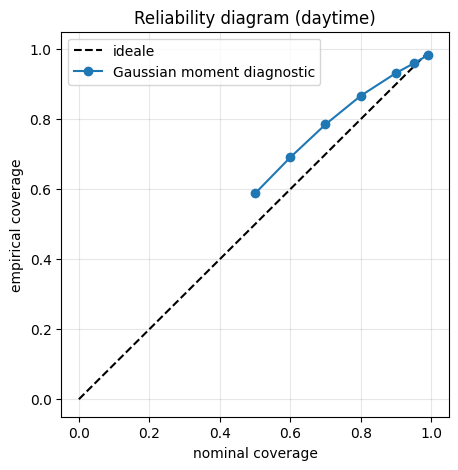

 nominal  empirical
    0.50     0.5878
    0.60     0.6909
    0.70     0.7851
    0.80     0.8669
    0.90     0.9319
    0.95     0.9593
    0.99     0.9826


In [11]:
import numpy as np, pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

# Predictions of the CURRENTLY SELECTED experiment — derive out_dir from
# BASE_CONFIG so a stale global out_dir can't point at the wrong run.
out_dir = pipe.make_out_dir(BASE_CONFIG)
PRED_CSV = str(Path(out_dir) / "predictions.csv")
print("reading:", PRED_CSV)
GAMMA, ETA = 0.95, 9.0
SOLAR_COL, SOLAR_THR = "solar_irradiance_poa_target", 10.0

# Primary intervals are exact quantiles of the sampled Gaussian mixture.
# A moment-matched Gaussian band is retained only as a diagnostic.
NLL_DIST = 'gaussian'
z = float(norm.ppf(0.5 + GAMMA / 2))

want = ["y_true", "y_pred_mean", "y_pred_std_raw", "lower_pi", "upper_pi",
        SOLAR_COL, "timestamp", "location"]
# Always load from the selected run's CSV (no stale in-memory df shortcut).
d = pd.read_csv(PRED_CSV, usecols=lambda c: c in want)

# --- daytime + finite ---
d = d[d[SOLAR_COL] > SOLAR_THR]
need = ["y_true", "y_pred_mean", "y_pred_std_raw"]
d = d[np.isfinite(d[need].to_numpy()).all(axis=1)].reset_index(drop=True)

y = d["y_true"].to_numpy(float)
mu = d["y_pred_mean"].to_numpy(float)
sig = d["y_pred_std_raw"].to_numpy(float)

rng = y.max() - y.min()                       # target_range (come report)
rmse = np.sqrt(np.mean((mu - y) ** 2))

clc = lambda picp, nmpil: nmpil * (1.0 + np.exp(-ETA * (picp - GAMMA)))  # = report CLC

def metrics(lo, hi, name):
    inside = (y >= lo) & (y <= hi)
    picp, mpiw = inside.mean(), np.mean(hi - lo)
    nmpil = mpiw / rng
    return dict(model=name, PICP=round(picp, 4), MPIW=round(mpiw, 2),
                NMPIL=round(nmpil, 4), MPIW_RMSE=round(mpiw / rmse, 3),
                CLC=round(clc(picp, nmpil), 4))

rows = []
# 1) modello, PI Gaussian-mixture primari salvati dal runner
rows.append(metrics(d["lower_pi"].to_numpy(float), d["upper_pi"].to_numpy(float), "model (saved PI)"))
# 2) diagnostica moment-matched Gaussian sulla varianza totale
rows.append(metrics(mu - z * sig, mu + z * sig, "model (Gaussian moment diagnostic)"))
# No test-fitted homoscedastic/climatology baselines: fitting them on y_test
# would leak evaluation targets and they are not part of this primary run.

res = pd.DataFrame(rows)[["model", "PICP", "MPIW", "NMPIL", "MPIW_RMSE", "CLC"]]
print(f"dist={NLL_DIST}" +
      f"  target_range={rng:.2f}  RMSE={rmse:.2f}  gaussian_z={z:.3f}  (gamma={GAMMA}, eta={ETA})")
print(res.to_string(index=False))
ood_smoke_path = Path(out_dir) / 'ood_smoke_metrics.csv'
if ood_smoke_path.exists():
    print('\nControlled pseudo-OOD smoke test (not real held-out OOD):')
    print(pd.read_csv(ood_smoke_path).to_string(index=False))

# --- reliability diagram della sola diagnostica Gaussian moment-matched ---
levels = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99])
emp = np.array([((y >= mu - norm.ppf(.5 + L / 2) * sig) & (y <= mu + norm.ppf(.5 + L / 2) * sig)).mean() for L in levels])
plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], "k--", label="ideale")
plt.plot(levels, emp, "o-", label="Gaussian moment diagnostic")
plt.xlabel("nominal coverage"); plt.ylabel("empirical coverage")
plt.title("Reliability diagram (daytime)"); plt.legend(); plt.grid(alpha=.3); plt.show()
print(pd.DataFrame({"nominal": levels, "empirical": np.round(emp, 4)}).to_string(index=False))

In [12]:
# I grafici usano le statistiche esatte calcolate su tutte le righe dal report.
figure_paths = pipe.build_posthoc_figures(out_dir)
print('figures:', list(figure_paths))

figures: ['mae_daytime_0_20_pct_boxplot', 'mae_daytime_20_40_pct_boxplot', 'mae_daytime_40_60_pct_boxplot', 'mae_daytime_60_80_pct_boxplot', 'mae_daytime_80_100_pct_boxplot', 'nmpil_daytime_0_20_pct_boxplot', 'nmpil_daytime_20_40_pct_boxplot', 'nmpil_daytime_40_60_pct_boxplot', 'nmpil_daytime_60_80_pct_boxplot', 'nmpil_daytime_80_100_pct_boxplot', 'picp_daytime_0_20_pct_bar', 'picp_daytime_20_40_pct_bar', 'picp_daytime_40_60_pct_bar', 'picp_daytime_60_80_pct_bar', 'picp_daytime_80_100_pct_bar', 'clc_daytime_0_20_pct_bar', 'clc_daytime_20_40_pct_bar', 'clc_daytime_40_60_pct_bar', 'clc_daytime_60_80_pct_bar', 'clc_daytime_80_100_pct_bar', 'rmse_daytime_0_20_pct_bar', 'rmse_daytime_20_40_pct_bar', 'rmse_daytime_40_60_pct_bar', 'rmse_daytime_60_80_pct_bar', 'rmse_daytime_80_100_pct_bar', 'uncertainty_components_bar']


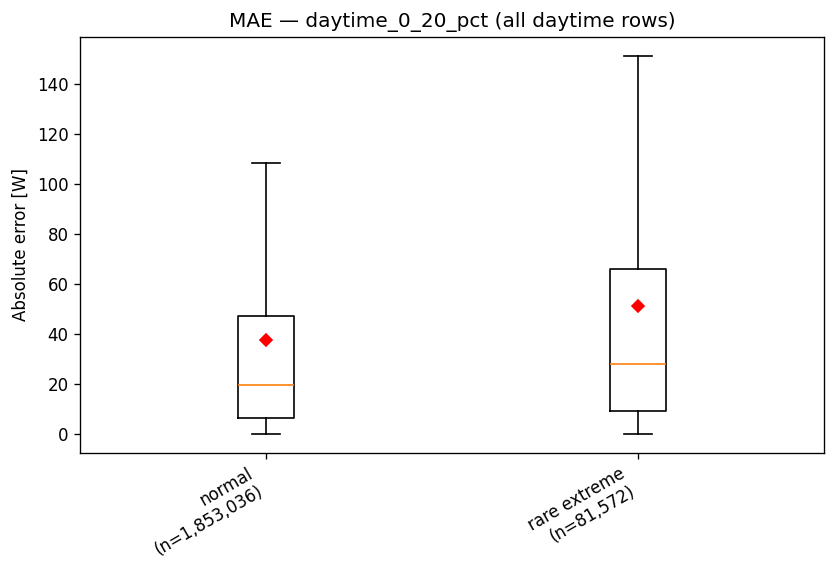

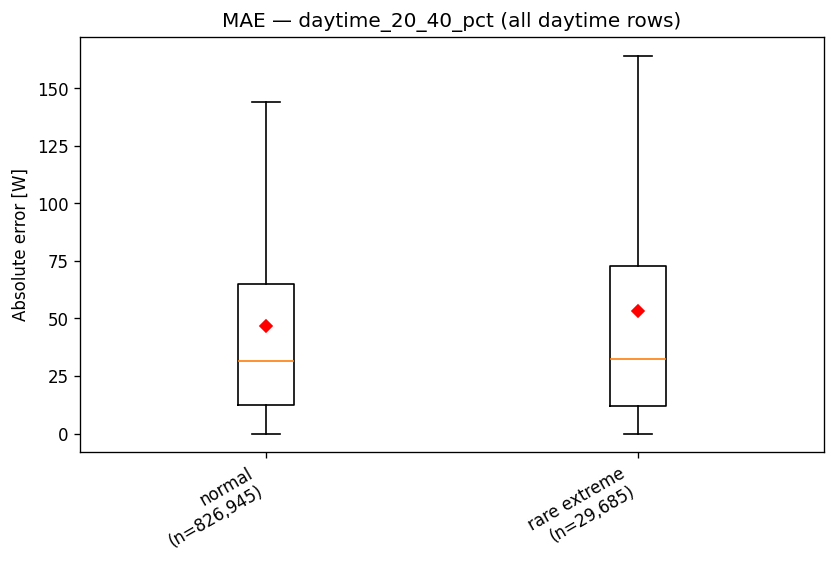

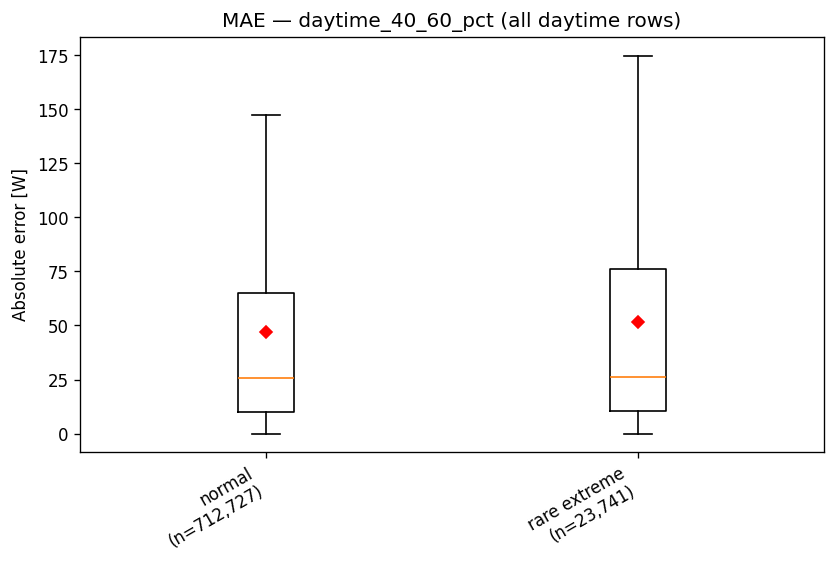

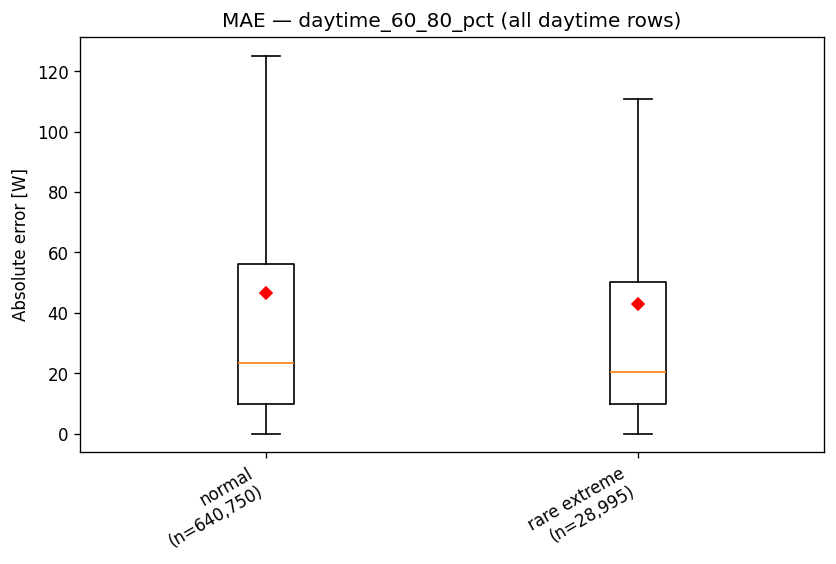

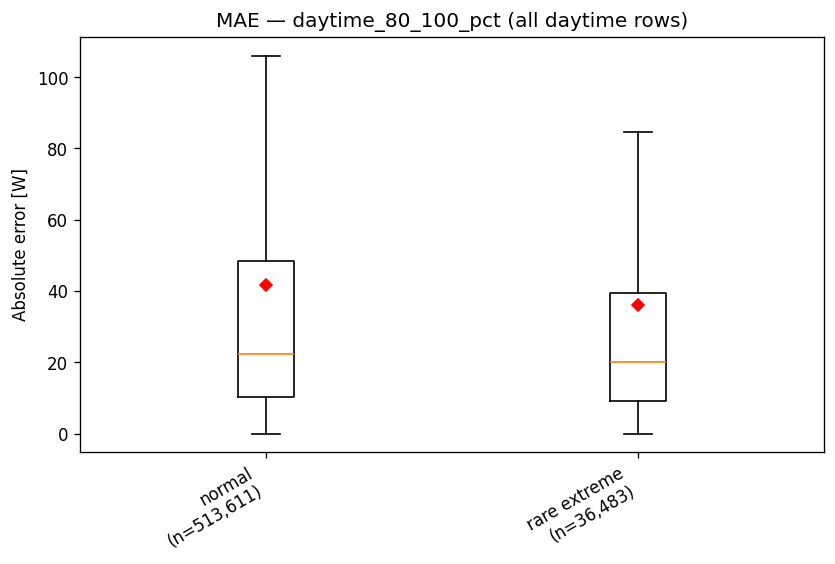

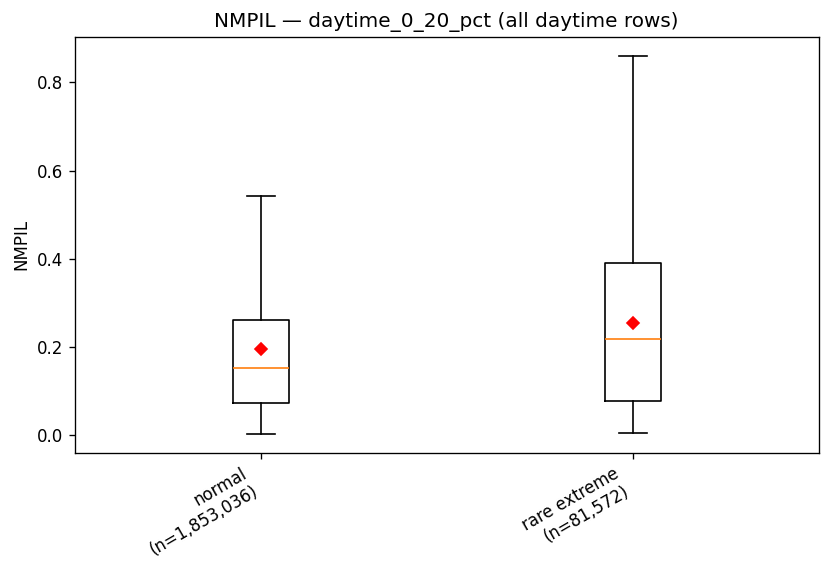

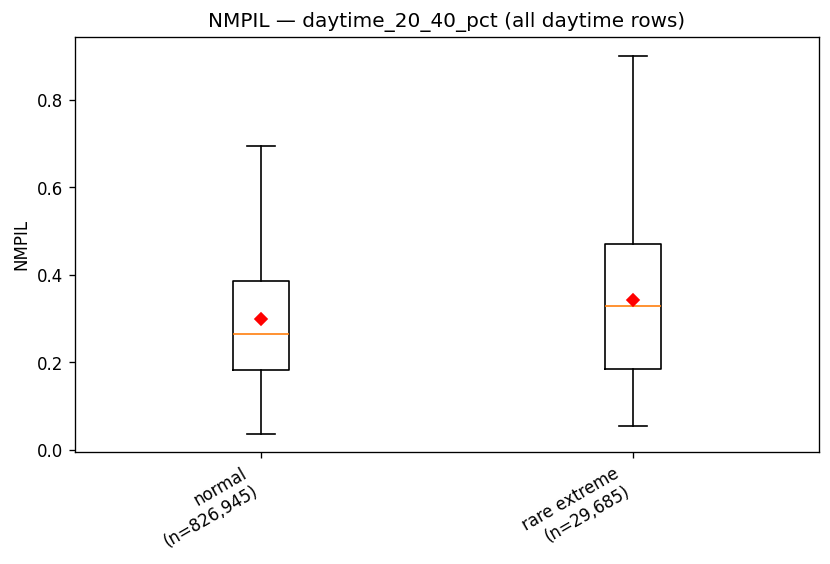

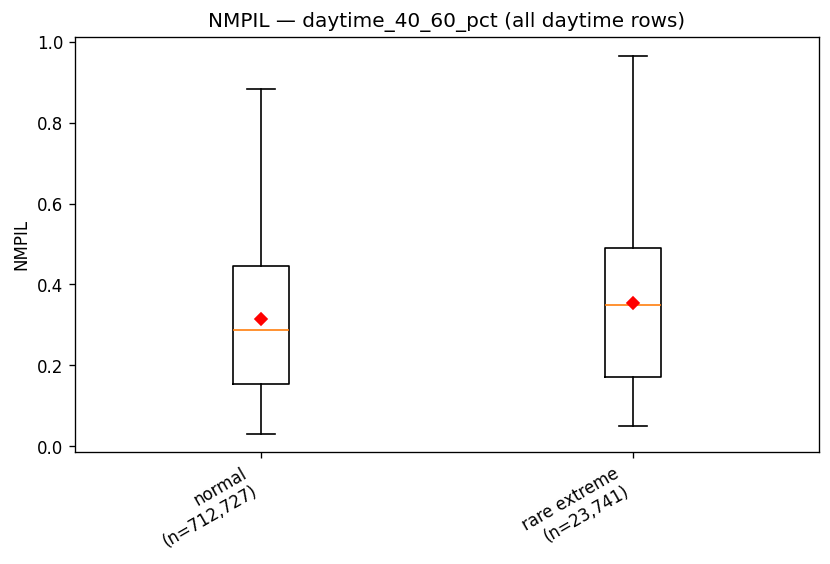

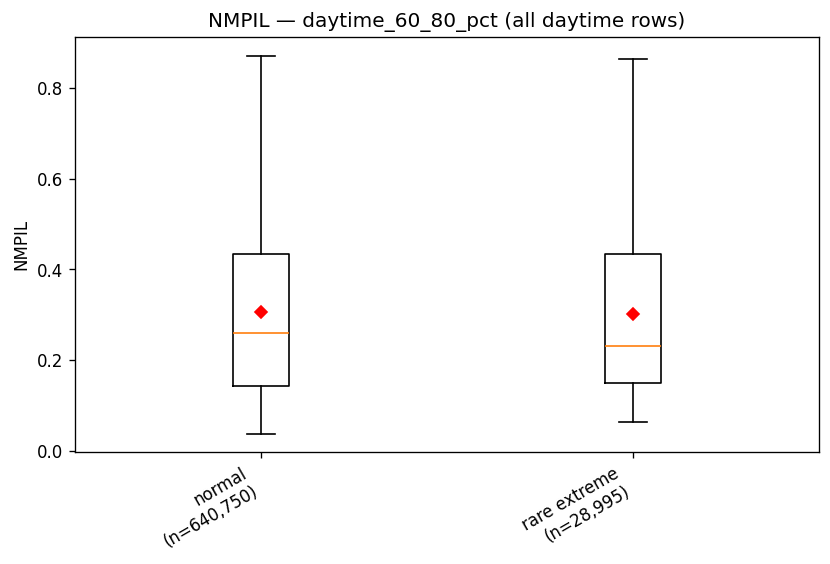

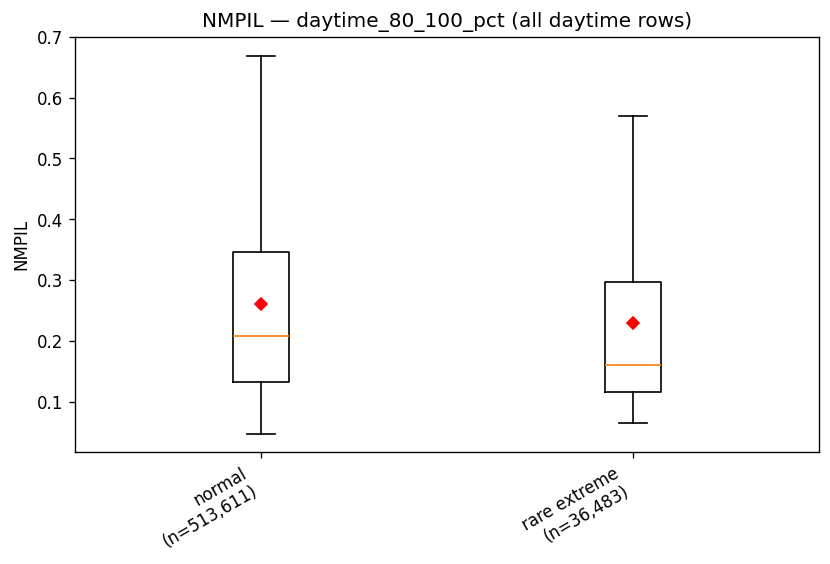

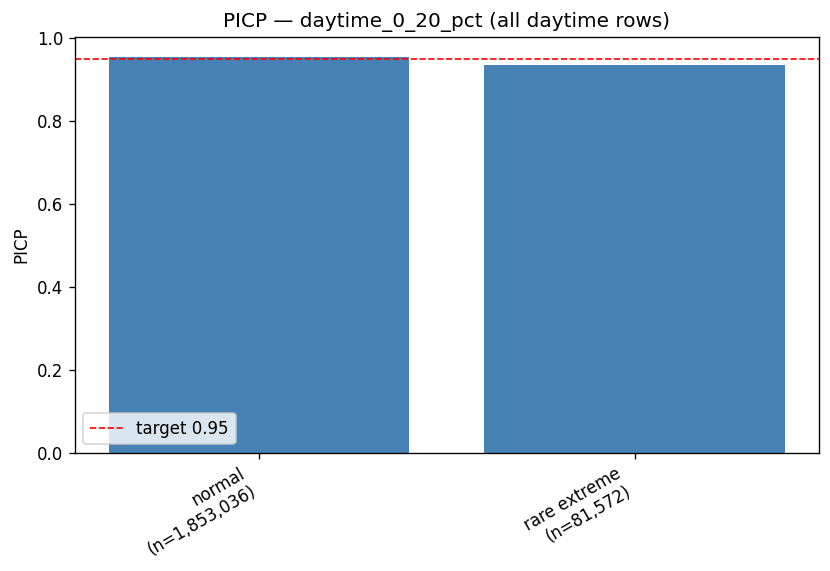

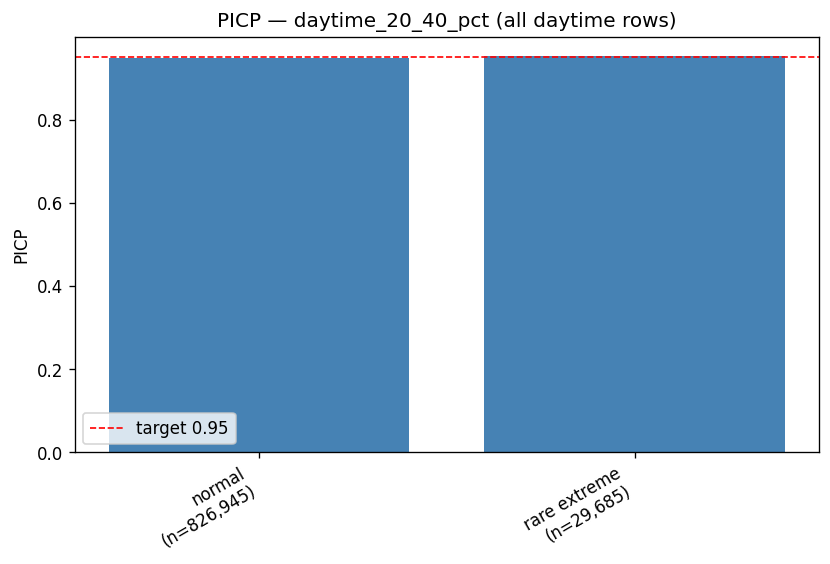

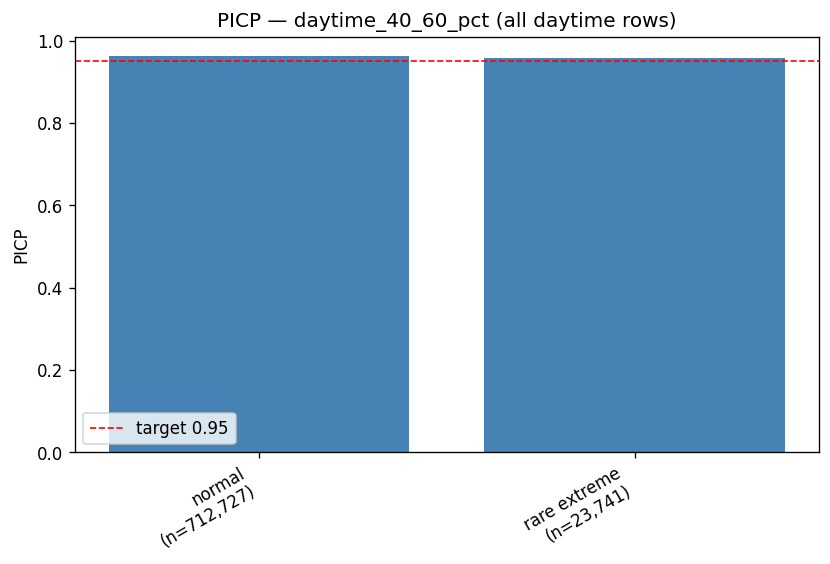

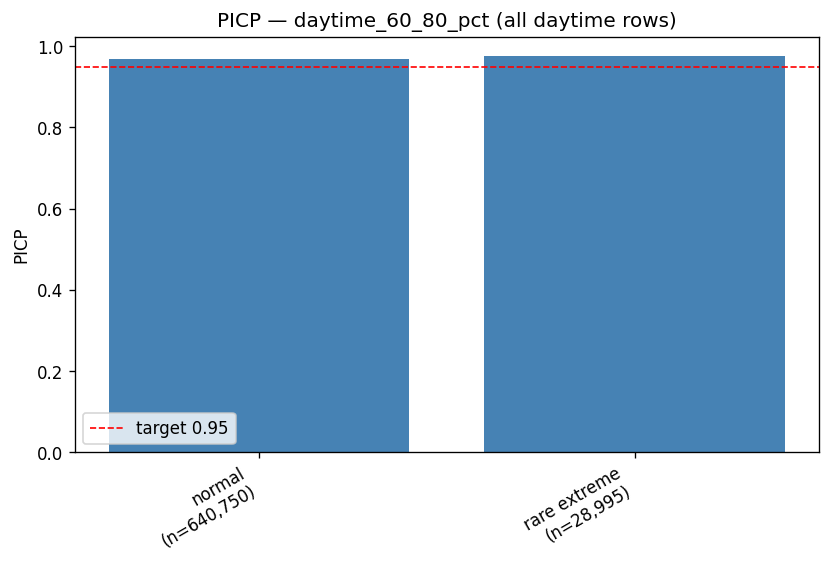

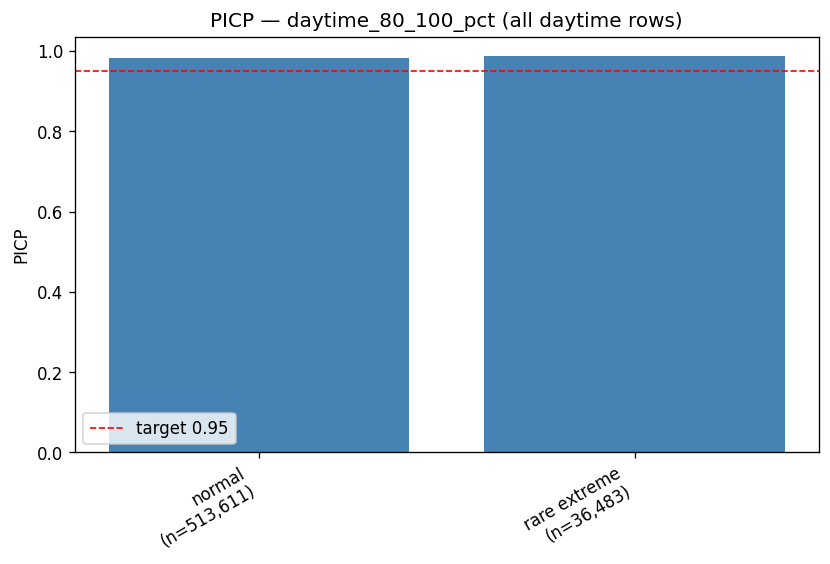

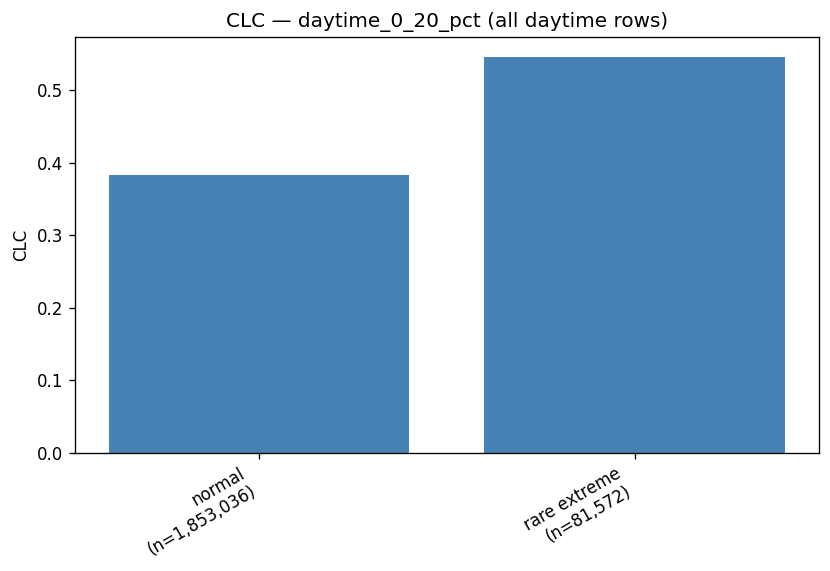

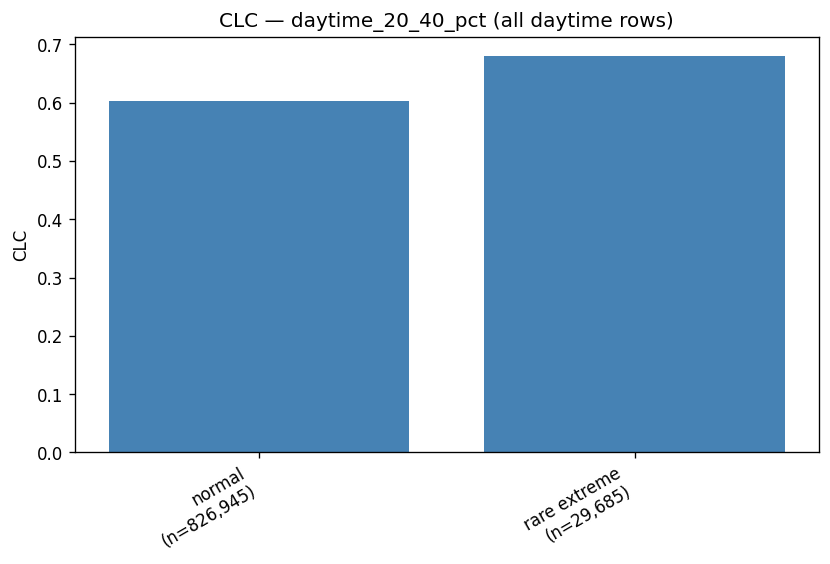

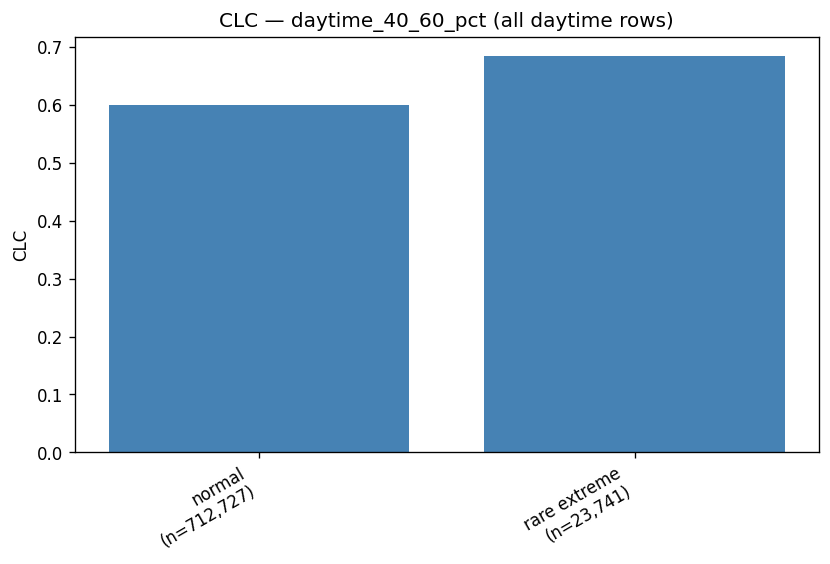

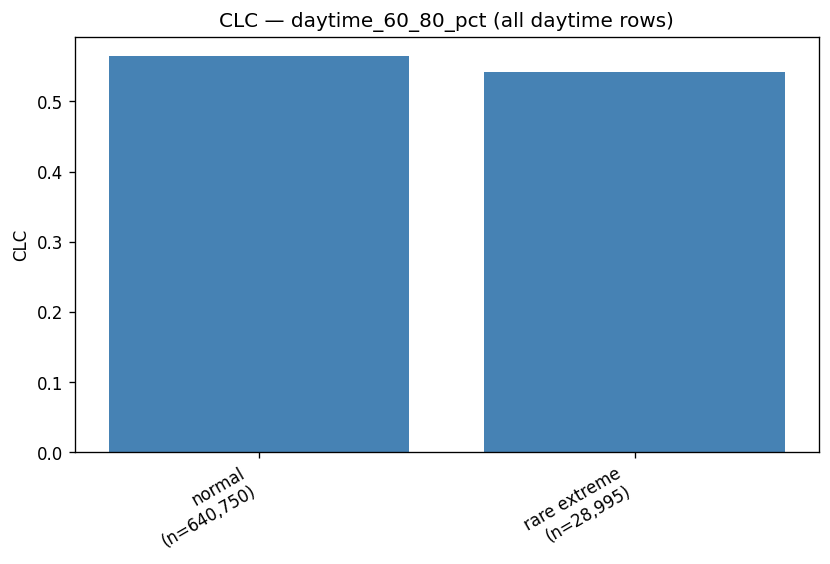

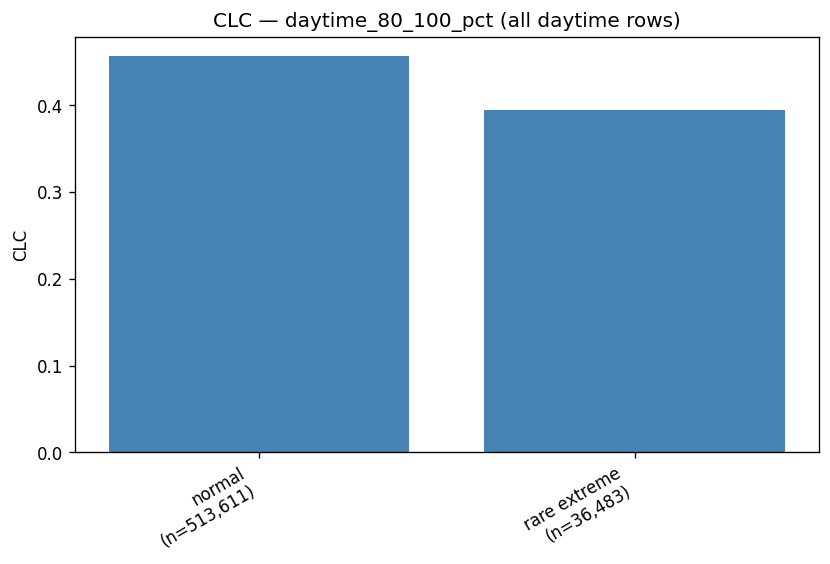

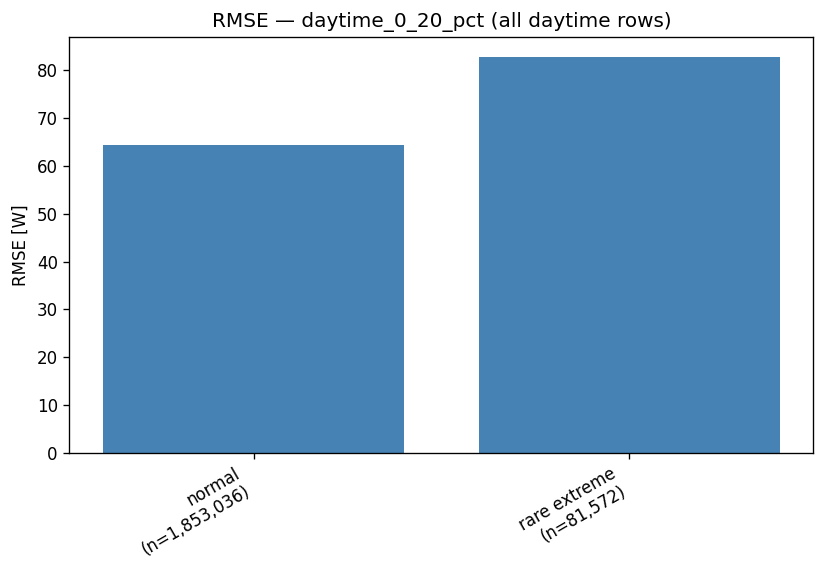

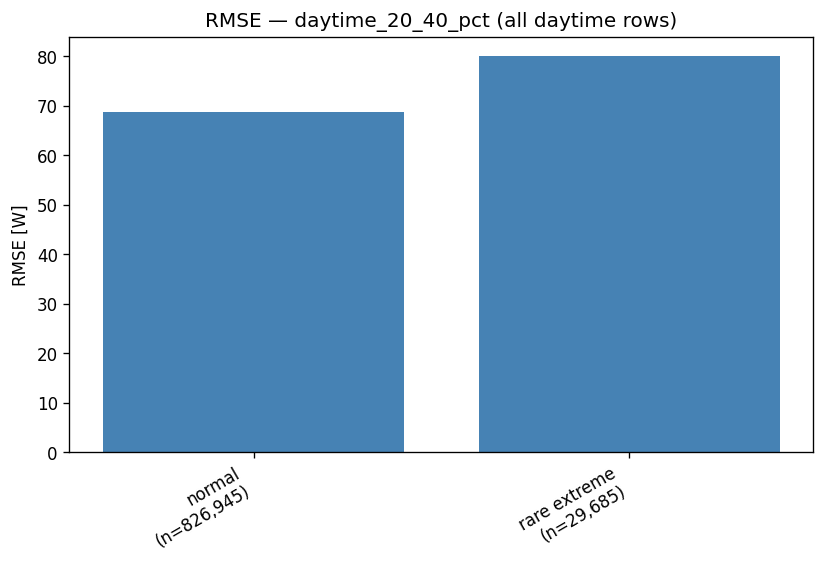

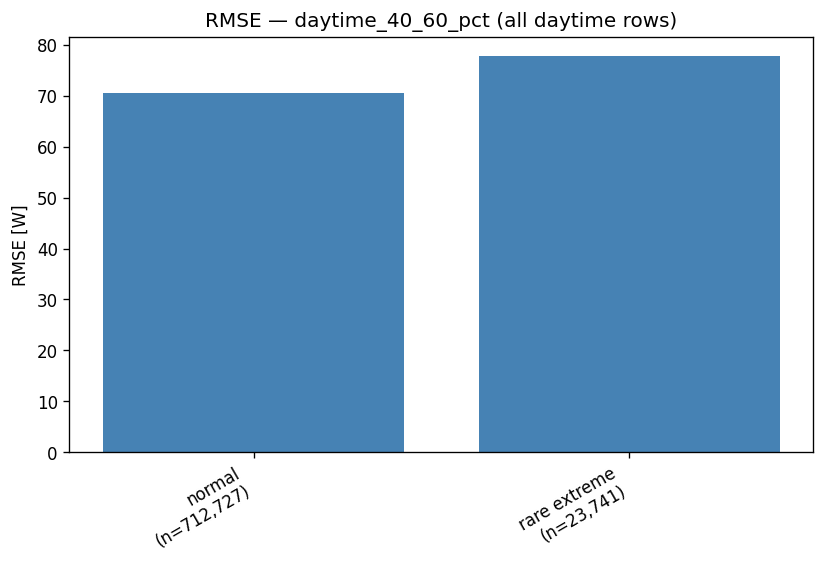

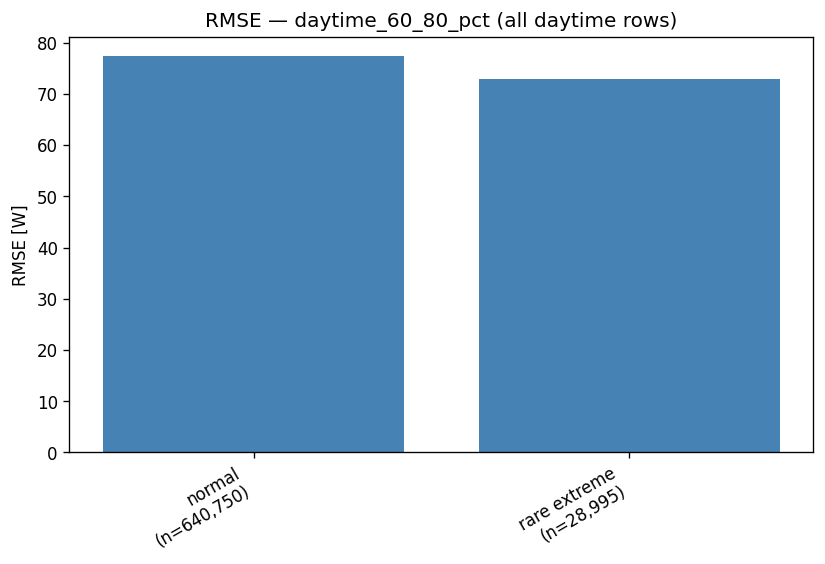

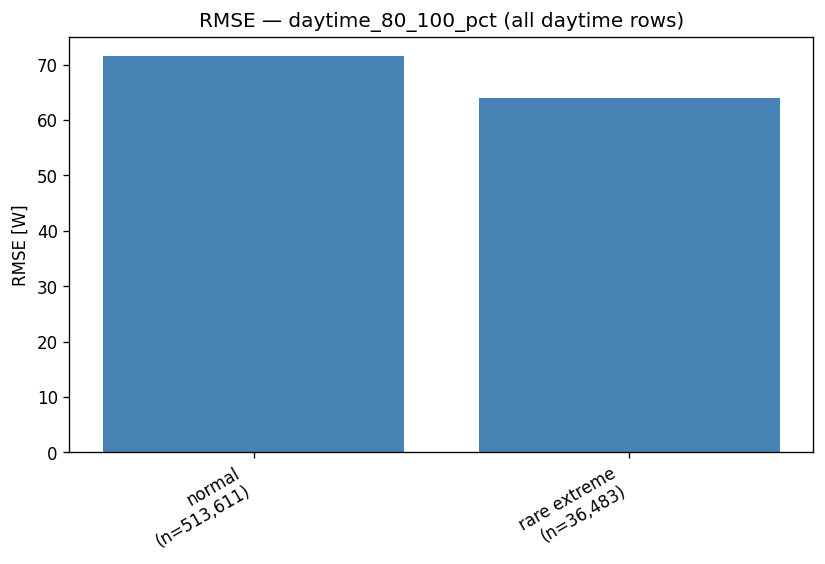

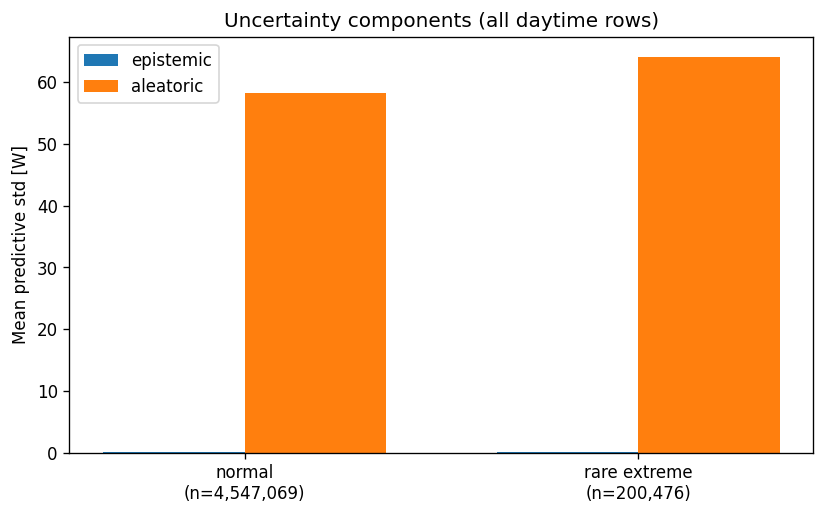

In [13]:
if figure_paths:
    from IPython.display import Image, display
    for path in figure_paths.values():
        display(Image(filename=str(path)))

## 7. W&B sweep (optional)

In [ ]:
print('Sweep disabled: this notebook defines one controlled exploratory run.')

In [ ]:
# Intentionally no W&B sweep registration in the single-run notebook.

## 8. Log post-hoc results to W&B (optional)

Adds post-hoc scalars and figures to the matching W&B run without uploading artifacts.
The sweep wrapper does this automatically per run.

In [ ]:
LOG_TO_WANDB = True
if LOG_TO_WANDB:
    import wandb
    run = pipe.init_wandb_run_for_out_dir(wandb, out_dir, run_name=run_name)
    try:
        posthoc = pipe.log_posthoc_to_wandb(
            wandb, run, out_dir,
            figure_paths=figure_paths if 'figure_paths' in dir() else None,
            upload_artifact=False,
        )
        print(posthoc['summary'])
        print('posthoc artifact upload disabled; uploaded:', posthoc['artifact_uploaded'])
    finally:
        run.finish()
else:
    print('LOG_TO_WANDB is False. posthoc summary preview:')
    if Path(out_dir, 'sharpness_overview.csv').exists():
        print(pipe.read_posthoc_summary(out_dir))